### Model Monitoring Simulation

In this notebook, we simulate a simple monitoring system for a deployed machine learning model. We track prediction performance over multiple batches of incoming data and detect potential performance degradation.

In [1]:
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score

In [2]:
model = joblib.load("calibrated_rf.pkl")
threshold = joblib.load("best_cost_threshold.pkl")

X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

####  Batch Prediction Simülation


In [3]:
# split test set
batch_size = 50

batches_X = [X_test[i:i+batch_size] for i in range(0, len(X_test), batch_size)]
batches_y = [y_test[i:i+batch_size] for i in range(0, len(y_test), batch_size)]

In [4]:
monitoring_results = []

for i, (X_batch, y_batch) in enumerate(zip(batches_X, batches_y)):

    y_proba = model.predict_proba(X_batch)[:,1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_batch, y_pred)
    f1 = f1_score(y_batch, y_pred)

    monitoring_results.append({
        "batch": i,
        "accuracy": acc,
        "f1": f1
    })

monitor_df = pd.DataFrame(monitoring_results)

monitor_df

,batch,accuracy,f1
0,0,0.720000,0.611111
1,1,0.680000,0.692308
2,2,0.700000,0.615385
3,3,0.680000,0.500000
4,4,0.780000,0.645161
5,5,0.416667,0.461538


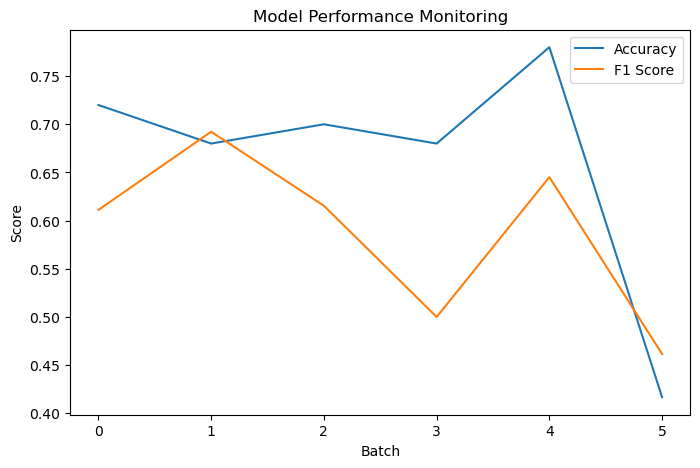

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(monitor_df["batch"], monitor_df["accuracy"], label="Accuracy")
plt.plot(monitor_df["batch"], monitor_df["f1"], label="F1 Score")

plt.xlabel("Batch")
plt.ylabel("Score")
plt.title("Model Performance Monitoring")

plt.legend()
plt.show()

In [6]:
alert_threshold = 0.55

alerts = monitor_df[monitor_df["f1"] < alert_threshold]

alerts

,batch,accuracy,f1
3,3,0.680000,0.500000
5,5,0.416667,0.461538


### In this experiment, model performance was monitored across multiple data batches to simulate a simple production monitoring system. Most batches show relatively stable accuracy and F1 scores, indicating consistent model behavior across incoming data. However, the last batch shows a noticeable performance drop, which could indicate potential data drift or an unusual batch composition. In real-world deployment scenarios, such monitoring mechanisms are essential to detect performance degradation and trigger investigation or retraining processes.